In [ ]:
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt

df = pd.read_csv('Dados/conjuntoDeDados_com_grau_distancia.tsv', sep='\t', decimal = ',', encoding = 'UTF-8') 

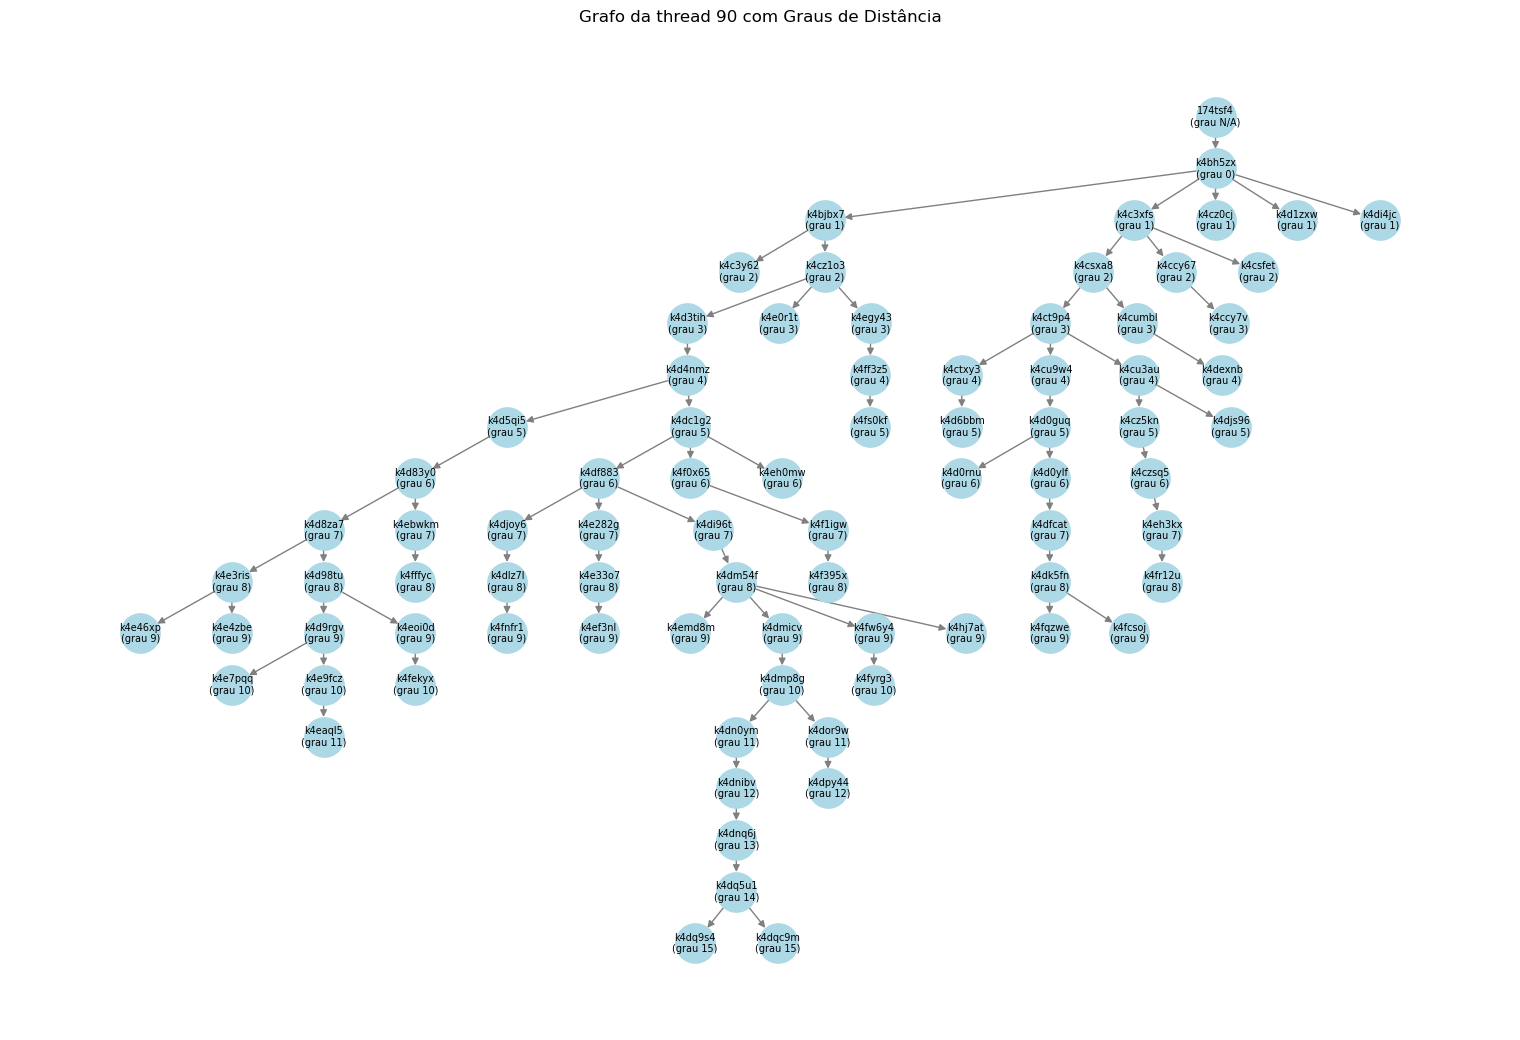

=== ESTATÍSTICAS DA THREAD 90 ===
Total de comentários: 80
Comentários com grau calculado: 80
Grau máximo: 9.0


TypeError: Could not convert string '0.01.02.02.03.04.05.06.07.08.09.09.08.09.010.010.011.09.010.07.08.05.06.07.08.09.07.08.09.07.08.09.09.010.011.012.013.014.015.015.011.012.09.010.09.06.07.08.06.03.03.04.05.01.02.03.04.05.04.05.06.06.07.08.09.09.04.05.06.07.08.05.03.04.02.03.02.01.01.01.0' to numeric

In [3]:
def criar_grafo(df):
    # Crie um grafo direcionado
    G = nx.DiGraph()

    # Adicione nós (comentários) com atributos
    for idx, row in df.iterrows():
        # Adicionar nó com atributos incluindo grau de distância
        node_attrs = {
            'grau_distancia': row.get('grau_distancia', 'N/A'),
            'label': row.get('label', 'N/A'),
            'author': row.get('author', 'N/A')
        }
        G.add_node(row['id'], **node_attrs)

    # Adicione arestas de parent (resposta)
    for idx, row in df.iterrows():
        if pd.notnull(row['parent_id']):
            G.add_edge(row['parent_id'], row['id'], relation='parent')

    return G

G = criar_grafo(df)

# Visualização hierárquica (top-down) com grau de distância
def visualizar_grafo(G, titulo='Grafo de comentários'):
    plt.figure(figsize=(15, 10))
    pos = nx.nx_agraph.graphviz_layout(G, prog='dot')  # ou: nx.nx_pydot.graphviz_layout(G, prog='dot')
    
    # Criar labels personalizados incluindo grau de distância
    labels = {}
    for node in G.nodes():
        grau = G.nodes[node].get('grau_distancia', 'N/A')
        if pd.notna(grau) and grau != 'N/A':
            labels[node] = f"{node}\n(grau {int(float(grau))})"
        else:
            labels[node] = f"{node}\n(grau N/A)"
    
    # Desenhar o grafo com labels personalizados
    nx.draw(G, pos, 
            labels=labels,
            node_size=800, 
            font_size=7, 
            arrows=True,
            node_color='lightblue',
            edge_color='gray',
            with_labels=True)
    
    plt.title(titulo)
    plt.show()

# df de uma thread específica
thread_id = 90
df_postagem = df[df['target_id'] == thread_id]  # target_id é o id da thread. Os demais ids em colunas são de comentários em relação a esta.

G_postagem = criar_grafo(df_postagem)
visualizar_grafo(G_postagem, titulo='Grafo da thread ' + str(thread_id) + ' com Graus de Distância')

# Mostrar estatísticas da thread
print(f"=== ESTATÍSTICAS DA THREAD {thread_id} ===")
print(f"Total de comentários: {len(df_postagem)}")
print(f"Comentários com grau calculado: {df_postagem['grau_distancia'].notna().sum()}")
print(f"Grau máximo: {df_postagem['grau_distancia'].max()}")
print(f"Grau médio: {df_postagem['grau_distancia'].mean():.2f}")

# Distribuição dos graus nesta thread
print("\nDistribuição dos graus:")
graus_distribuicao = df_postagem['grau_distancia'].value_counts().sort_index()
for grau, count in graus_distribuicao.items():
    if pd.notna(grau):
        print(f"  Grau {int(grau)}: {count} comentários")